# FLMVDM Noise Schedule Explorer

Use this notebook to sample `tau` values and inspect how each FLMVDM schedule maps them to `gamma`, `SNR`, `alpha`, and VLB/SNR-prime weights. The time convention is the FLM convention: `tau=0` is noise and `tau=1` is data.

In [ ]:
# Main controls
SCHEDULE_TYPE = "argmax_uncertainty"  # linear, learned_vdm, argmax_uncertainty, snr_power
LATENT_TYPE = "linear_interp"           # vp or linear_interp
IMPORTANCE_SAMPLING = True

N_SAMPLES = 10_000
GRID_POINTS = 1_000
SEED = 0

# Use a clipped interval for schedules with singular endpoints, especially snr_power.
T_MIN = 0
T_MAX = 1.0 #0.999

SCHEDULE_PARAMS = {
    "gamma_min": -3.5,
    "gamma_max": 3.0,
    "C": 17.276323318481445,
    "p": 0.43169814348220825,
    "eps": 1e-6,
    "hidden_size": 128,
    "vocab_size": 30_522, #50_257,
    # Lower this for fast interactive argmax_uncertainty exploration.
    "n_points": 2_000,
    "n_gh": 64,
}

In [117]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import noise_schedules

torch.set_default_dtype(torch.float64)
plt.style.use("seaborn-v0_8-whitegrid")

In [118]:
def make_schedule(schedule_type=SCHEDULE_TYPE, params=SCHEDULE_PARAMS):
    return noise_schedules.build_noise_schedule(
        schedule_type,
        vocab_size=params["vocab_size"],
        gamma_min=params["gamma_min"],
        gamma_max=params["gamma_max"],
        C=params["C"],
        p=params["p"],
        eps=params["eps"],
        hidden_size=params["hidden_size"],
        n_points=params["n_points"],
        n_gh=params["n_gh"],
    ).eval()


def alpha_sigma_from_gamma(gamma, latent_type=LATENT_TYPE):
    if latent_type == "vp":
        alpha = torch.sigmoid(-gamma).sqrt()
        sigma = torch.sigmoid(gamma).sqrt()
    elif latent_type in {"linear", "linear_interp"}:
        alpha = torch.sigmoid(-0.5 * gamma)
        sigma = torch.sigmoid(0.5 * gamma)
    else:
        raise ValueError(f"Unknown latent_type: {latent_type}")
    return alpha, sigma


def uniform_tau(n=N_SAMPLES, t_min=T_MIN, t_max=T_MAX, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return t_min + (t_max - t_min) * torch.rand(n, generator=generator)


def evaluate(schedule, tau, latent_type=LATENT_TYPE):
    gamma, snr_prime = schedule(tau)
    snr = torch.exp(-gamma)
    alpha, sigma = alpha_sigma_from_gamma(gamma, latent_type=latent_type)
    return {
        "tau": tau.detach(),
        "gamma": gamma.detach(),
        "snr": snr.detach(),
        "alpha": alpha.detach(),
        "sigma": sigma.detach(),
        "snr_prime": snr_prime.detach(),
    }


def evaluate_importance(schedule, n=N_SAMPLES, t_max=T_MAX, seed=SEED,
                        latent_type=LATENT_TYPE):
    generator = torch.Generator().manual_seed(seed)
    unit = torch.rand(n, generator=generator)
    tau, gamma, vlb_weight = schedule.importance_sample(unit, t_max=t_max)
    snr = torch.exp(-gamma)
    alpha, sigma = alpha_sigma_from_gamma(gamma, latent_type=latent_type)
    return {
        "unit": unit.detach(),
        "tau": tau.detach(),
        "gamma": gamma.detach(),
        "snr": snr.detach(),
        "alpha": alpha.detach(),
        "sigma": sigma.detach(),
        "vlb_weight": vlb_weight.detach(),
    }


def to_numpy(values):
    return values.detach().cpu().numpy()


def summarize(values, names):
    rows = []
    for name in names:
        arr = to_numpy(values[name])
        rows.append((name, arr.mean(), arr.std(), arr.min(), np.median(arr), arr.max()))
    print(f"{'value':<12} {'mean':>13} {'std':>13} {'min':>13} {'median':>13} {'max':>13}")
    for row in rows:
        print(f"{row[0]:<12} {row[1]:13.6g} {row[2]:13.6g} {row[3]:13.6g} {row[4]:13.6g} {row[5]:13.6g}")

## Inspect One Schedule

This section samples taus uniformly from `[T_MIN, T_MAX]` unless `IMPORTANCE_SAMPLING=True`, in which case it samples uniformly in SNR space and reports the effective tau.

In [119]:
schedule = make_schedule(SCHEDULE_TYPE)

if IMPORTANCE_SAMPLING:
    sampled = evaluate_importance(schedule)
    value_names = ["tau", "gamma", "snr", "alpha", "sigma", "vlb_weight"]
else:
    tau_samples = uniform_tau()
    sampled = evaluate(schedule, tau_samples)
    value_names = ["tau", "gamma", "snr", "alpha", "sigma", "snr_prime"]

print(type(schedule).__name__)
summarize(sampled, value_names)

ArgmaxUncertaintySchedule
value                 mean           std           min        median           max
tau               0.471942      0.336094   4.76569e-05      0.496358      0.941751
gamma             -2.51606      0.999213      -3.50688      -2.82423        6.3842
snr                16.7848       9.63049    0.00168802       16.8479       33.3441
alpha             0.769237     0.0999404     0.0394641      0.804099      0.852386
sigma             0.230763     0.0999404      0.147614      0.195901      0.960536
vlb_weight         33.3489   7.10543e-15       33.3489       33.3489       33.3489


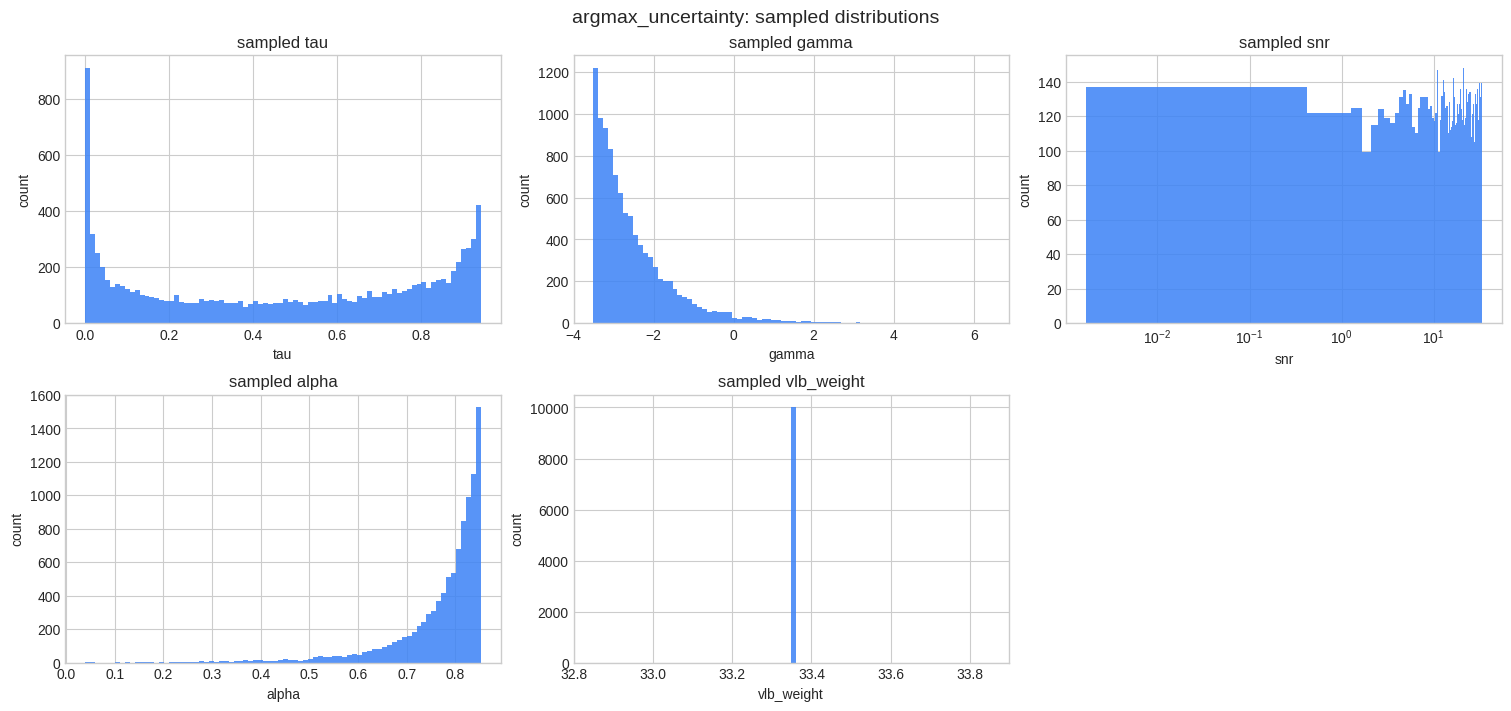

In [120]:
hist_names = [name for name in value_names if name != "sigma"]
fig, axes = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
axes = axes.ravel()

for ax, name in zip(axes, hist_names):
    arr = to_numpy(sampled[name])
    ax.hist(arr, bins=80, color="#3b82f6", alpha=0.85)
    ax.set_title(f"sampled {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("count")
    if name in {"snr", "snr_prime", "vlb_weight"} and np.nanmax(arr) / max(np.nanmin(arr[arr > 0]), 1e-300) > 100:
        ax.set_xscale("log")

for ax in axes[len(hist_names):]:
    ax.axis("off")

fig.suptitle(f"{SCHEDULE_TYPE}: sampled distributions", fontsize=14)
plt.show()

## Tau Curves

These plots show the deterministic schedule map from tau to gamma, SNR, alpha, and SNR-prime weight.

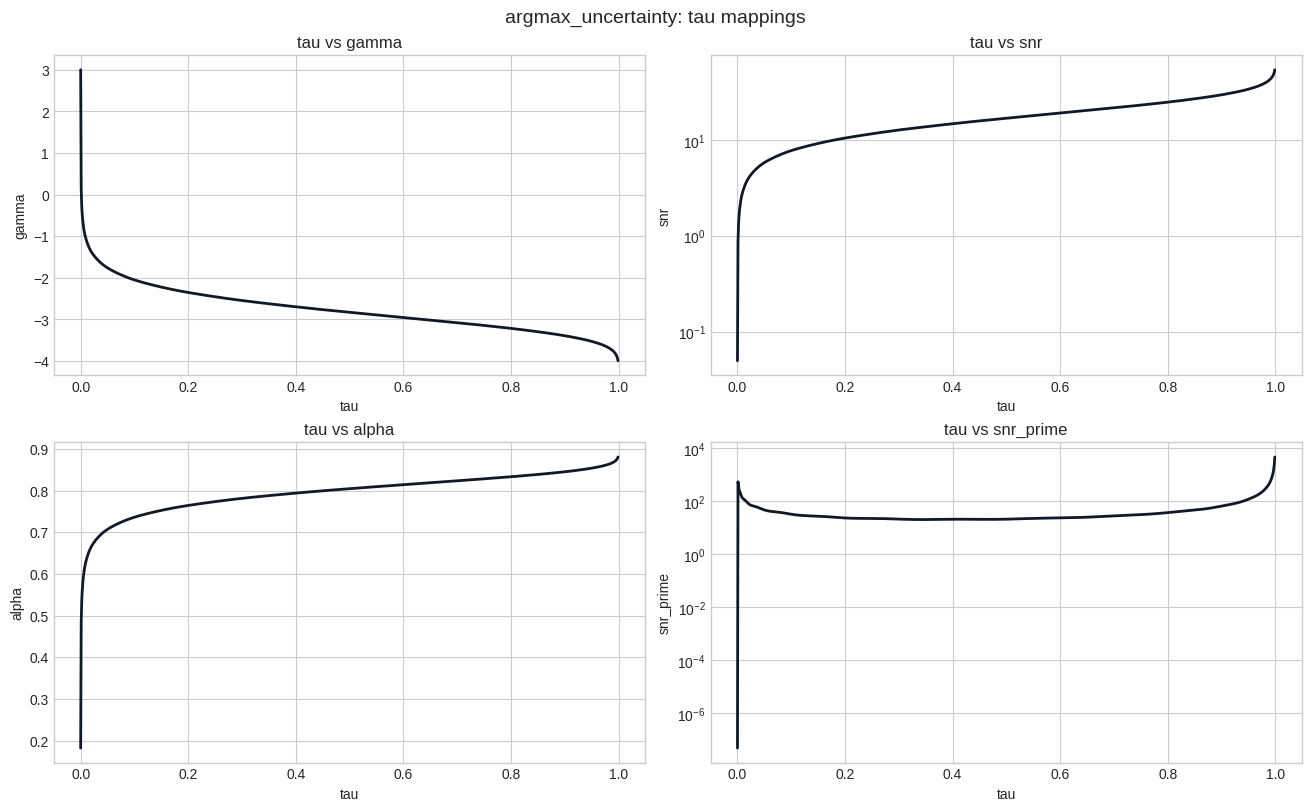

In [104]:
tau_grid = torch.linspace(T_MIN, T_MAX, GRID_POINTS)
curves = evaluate(schedule, tau_grid)

curve_specs = [
    ("gamma", "linear"),
    ("snr", "log"),
    ("alpha", "linear"),
    ("snr_prime", "log"),
]

fig, axes = plt.subplots(2, 2, figsize=(13, 8), constrained_layout=True)
axes = axes.ravel()
x = to_numpy(curves["tau"])

for ax, (name, scale) in zip(axes, curve_specs):
    y = to_numpy(curves[name])
    ax.plot(x, y, lw=2.0, color="#111827")
    ax.set_title(f"tau vs {name}")
    ax.set_xlabel("tau")
    ax.set_ylabel(name)
    if scale == "log":
        ax.set_yscale("log")

fig.suptitle(f"{SCHEDULE_TYPE}: tau mappings", fontsize=14)
plt.show()

## Compare All Schedules

This builds every schedule with the same config and overlays their tau curves. `argmax_uncertainty` is the most expensive to build; reduce `n_points` above if this cell is slow.

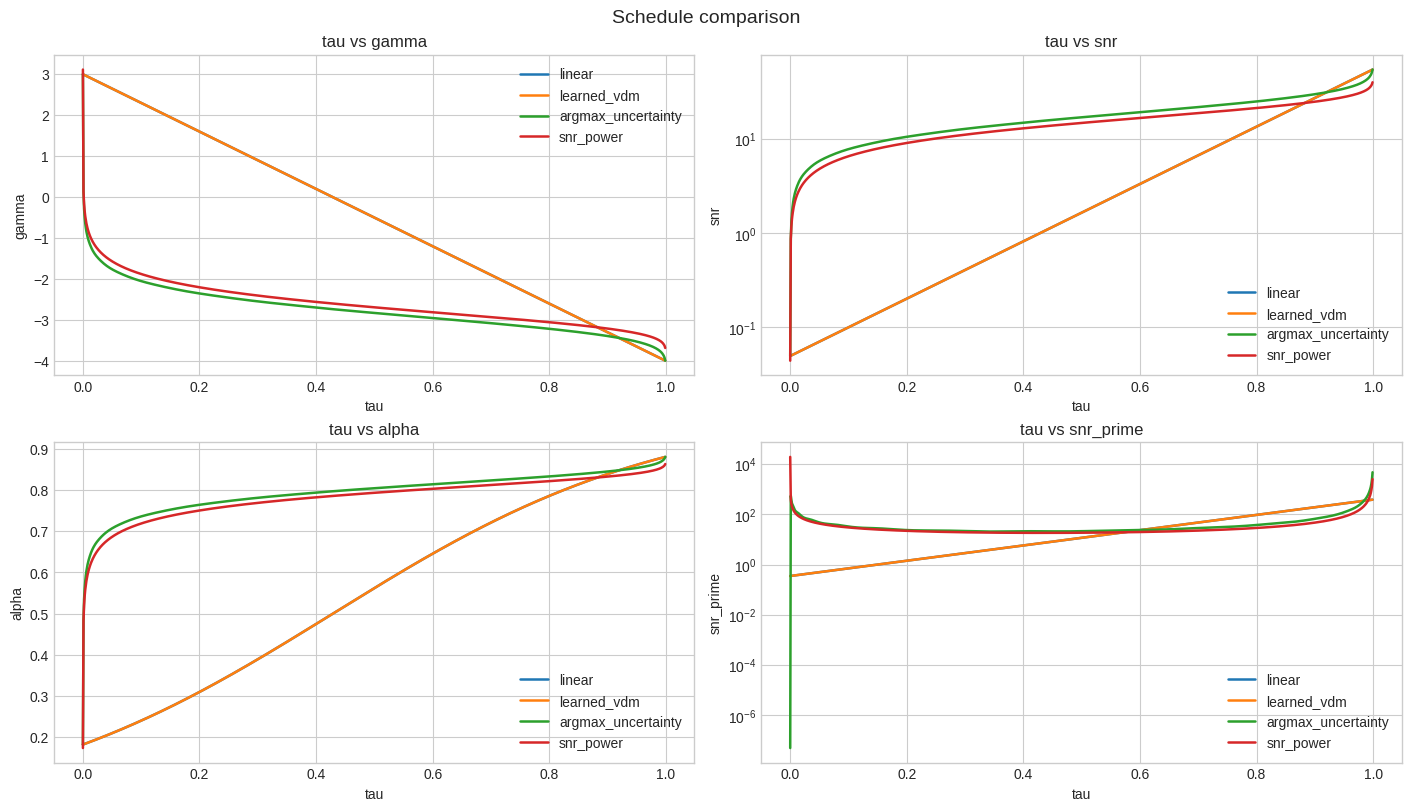

In [105]:
schedule_names = ["linear", "learned_vdm", "argmax_uncertainty", "snr_power"]
schedules = {name: make_schedule(name) for name in schedule_names}

fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)
axes = axes.ravel()

for name, sched in schedules.items():
    vals = evaluate(sched, tau_grid)
    for ax, (metric, scale) in zip(axes, curve_specs):
        ax.plot(to_numpy(vals["tau"]), to_numpy(vals[metric]), label=name, lw=1.8)
        ax.set_title(f"tau vs {metric}")
        ax.set_xlabel("tau")
        ax.set_ylabel(metric)
        if scale == "log":
            ax.set_yscale("log")

for ax in axes:
    ax.legend()

fig.suptitle("Schedule comparison", fontsize=14)
plt.show()

## Importance Sampling View

This samples uniformly in SNR space on `[0, SNR(T_MAX)]`, maps those samples back to gamma and effective tau, and shows the constant VLB weight.

value                 mean           std           min        median           max
tau               0.671488      0.362919   4.76569e-05       0.85899      0.998998
gamma             -3.00341      0.999213      -3.99423      -3.31157       5.89685
snr                27.3255       15.6783    0.00274807       27.4282       54.2838
alpha             0.807543     0.0923401     0.0498109      0.839671      0.880494
sigma             0.192457     0.0923401      0.119506      0.160329      0.950189
vlb_weight         54.2915             0       54.2915       54.2915       54.2915


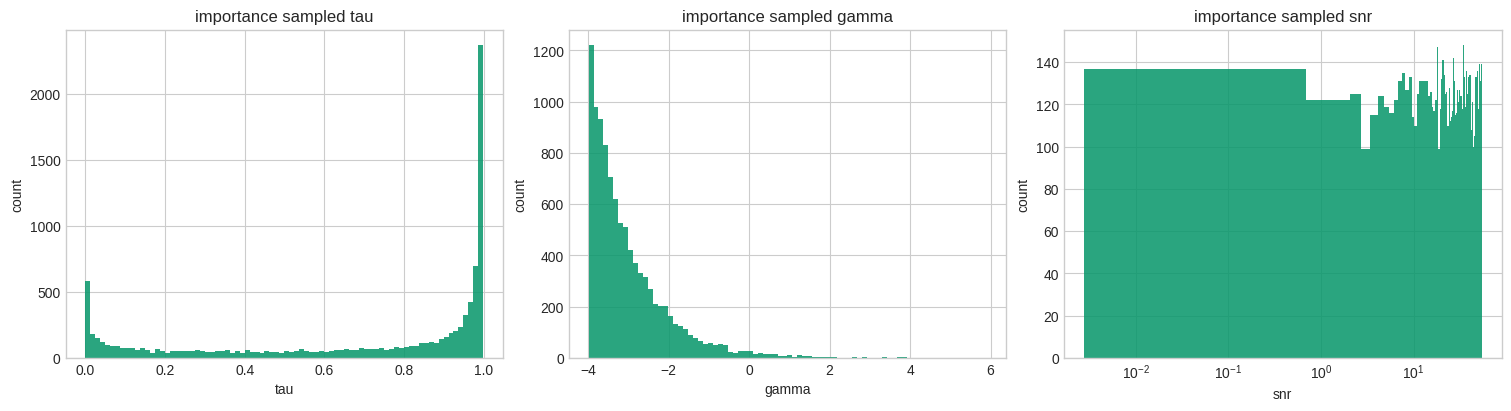

In [106]:
imp = evaluate_importance(schedule)
summarize(imp, ["tau", "gamma", "snr", "alpha", "sigma", "vlb_weight"])

fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, name in zip(axes, ["tau", "gamma", "snr"]):
    arr = to_numpy(imp[name])
    ax.hist(arr, bins=80, color="#059669", alpha=0.85)
    ax.set_title(f"importance sampled {name}")
    ax.set_xlabel(name)
    ax.set_ylabel("count")
    if name == "snr":
        ax.set_xscale("log")
plt.show()